In [1]:
import argparse
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
import seaborn as sns

from tqdm import trange

# sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))

import models

# from importlib import reload

# reload(models)

In [2]:
def logit_pi(rate):
    k = torch.arange(8, device=rate.device).float()
    return k * rate.log().unsqueeze(-1) - torch.lgamma(k + 1)


def ln_pi(rate):
    logits = logit_pi(rate)
    return logits - torch.logsumexp(logits, dim=-1, keepdim=True)


def aggregate_samples(gumbel_samples: torch.Tensor):
    k = torch.arange(8, device=gumbel_samples.device).float()
    return gumbel_samples @ k


def gumbel_log_prob(gumbel_samples, ln_pi):
    return -(-(gumbel_samples - ln_pi)).exp()

In [3]:
df_data = pd.read_pickle("data/data.pkl")
y_train = df_data.at[0, "y_train"]

n_vis_neurons = 3
n_hid_neurons = 2
n_monte_carlo = 50

In [4]:
df_list = []
for n_monte_carlo in [1, 10, 20, 50]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_time_bins, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        ).detach()  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(
            z_gs_samples
        )  # (batch, n_mc, n_time_bins, n_hid_neurons

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)
        p_logit_pi = logit_pi(
            p_rate[:, :, :, poglm.n_vis_neurons :]
        )  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            y_samples[:, :, :, : poglm.n_vis_neurons],
            p_rate[:, :, :, : poglm.n_vis_neurons],
        ).sum(dim=[-2, -1]) + models.gumbel_softmax_log_prob(
            z_gs_samples,
            p_logit_pi,
            temp=0.2,
        ).sum(
            dim=[-2, -1]
        )  # (batch, n_mc)
        ln_q = models.gumbel_softmax_log_prob(
            z_gs_samples,
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                poglm.n_hid_neurons,
                8,
            ),
            temp=0.2,
        ).sum(
            dim=[-2, -1]
        )  # (batch, n_mc)

        ln_p_values = ln_p.detach()
        ln_q_values = ln_q.detach()
        elbo_values = ln_p_values - ln_q_values
        elbo = (
            ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        ).mean(
            dim=-1
        )  # (batch,)
        loss = -elbo.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

In [5]:
for n_monte_carlo in [1, 10, 20, 50]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_time_bins, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        )  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(
            z_gs_samples
        )  # (batch, n_mc, n_time_bins, n_hid_neurons

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)
        p_logit_pi = logit_pi(
            p_rate[:, :, :, poglm.n_vis_neurons :]
        )  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            y_samples[:, :, :, : poglm.n_vis_neurons],
            p_rate[:, :, :, : poglm.n_vis_neurons],
        ).sum(dim=[-2, -1]) + models.gumbel_softmax_log_prob(
            z_gs_samples,
            # p_logit_pi.detach(),
            p_logit_pi,
            temp=0.2,
        ).sum(
            dim=[-2, -1]
        )  # (batch, n_mc)
        ln_q = models.gumbel_softmax_log_prob(
            z_gs_samples,
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                poglm.n_hid_neurons,
                8,
            ),
            temp=0.2,
        ).sum(
            dim=[-2, -1]
        )  # (batch, n_mc)

        elbo = (ln_p - ln_q).mean(dim=-1)  # (batch,)
        loss = -elbo.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["pathwise"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

df_results = pd.concat(df_list, axis=0, ignore_index=True)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

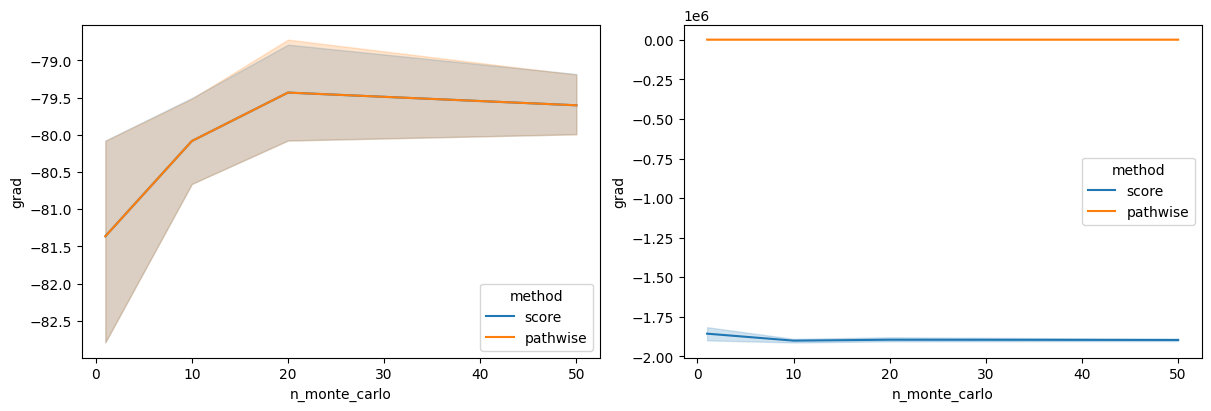

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[df_results["part"] == "generative"],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[df_results["part"] == "variational"],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

In [7]:
df_results[df_results["part"] == "variational"]

,n_monte_carlo,seed,method,part,grad
1,1,0,score,variational,-1.793372e+06
3,1,1,score,variational,-1.906771e+06
5,1,2,score,variational,-1.813973e+06
7,1,3,score,variational,-1.924396e+06
9,1,4,score,variational,-1.843948e+06
11,10,0,score,variational,-1.897106e+06
13,10,1,score,variational,-1.911212e+06
15,10,2,score,variational,-1.893574e+06
17,10,3,score,variational,-1.919404e+06
19,10,4,score,variational,-1.882148e+06


In [8]:
df_results[df_results["part"] == "variational"]

,n_monte_carlo,seed,method,part,grad
1,1,0,score,variational,-1.793372e+06
3,1,1,score,variational,-1.906771e+06
5,1,2,score,variational,-1.813973e+06
7,1,3,score,variational,-1.924396e+06
9,1,4,score,variational,-1.843948e+06
11,10,0,score,variational,-1.897106e+06
13,10,1,score,variational,-1.911212e+06
15,10,2,score,variational,-1.893574e+06
17,10,3,score,variational,-1.919404e+06
19,10,4,score,variational,-1.882148e+06


In [9]:
class Toy(nn.Module):
    def __init__(
        self,
        n_vis_neurons: int,
        n_hid_neurons: int,
        max_rate: float = 10,
    ):
        super().__init__()
        self.n_vis_neurons = n_vis_neurons
        self.n_hid_neurons = n_hid_neurons
        self.n_neurons = n_vis_neurons + n_hid_neurons
        self.max_rate = max_rate

        self.prior = nn.Parameter(torch.randn(n_hid_neurons))
        self.decoder = nn.Linear(n_hid_neurons, n_vis_neurons)
        self.encoder = nn.Linear(n_vis_neurons, n_hid_neurons)

In [10]:
df_list = []
for n_monte_carlo in [1, 10, 20, 50]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        ).detach()  # (batch, n_mc, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(z_gs_samples)  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)
        p_logit_pi = logit_pi(
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        )  # (batch, n_mc, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.gumbel_softmax_log_prob(
            z_gs_samples,
            p_logit_pi,
            temp=0.2,
            eps=1e-20,
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.gumbel_softmax_log_prob(
            z_gs_samples,
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
                8,
            ),
            temp=0.2,
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        # ln_p_values = ln_p.detach()
        # ln_q_values = ln_q.detach()
        # elbo_values = ln_p_values - ln_q_values
        # elbo = (
        #     ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        # ).mean(
        #     dim=-1
        # )  # (batch,)
        # loss = -elbo.mean()

        ln_q_values = ln_q.detach()
        f = (ln_q_values * ln_q).mean(dim=-1)  # (batch,)
        loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        0.0,
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )

In [11]:
for n_monte_carlo in [1, 10, 20, 50]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        )  # (batch, n_mc, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(z_gs_samples)  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)
        p_logit_pi = logit_pi(
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        )  # (batch, n_mc, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.gumbel_softmax_log_prob(
            z_gs_samples,
            p_logit_pi,
            temp=0.2,
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.gumbel_softmax_log_prob(
            z_gs_samples,
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
                8,
            ),
            temp=0.2,
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        # elbo = (ln_p - ln_q).mean(dim=-1)  # (batch,)
        # loss = -elbo.mean()
        f = ln_q.mean(dim=-1)  # (batch,)
        loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["pathwise"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        # toy.prior.grad[0].item(),
                        0.0,
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )
df_results = pd.concat(df_list, axis=0, ignore_index=True)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

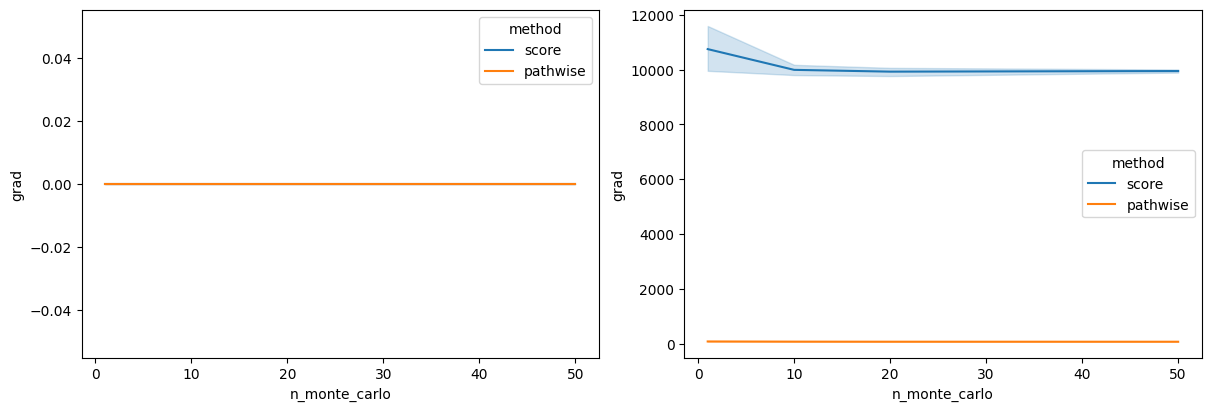

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[df_results["part"] == "generative"],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[df_results["part"] == "variational"],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

In [13]:
# torch.manual_seed(0)

mu = torch.tensor(1.3, requires_grad=True)
sigma = 0.7
N = 1000

# ========= pathwise =========
eps = torch.randn(N)
z = mu + sigma * eps
loss_pw = (z**4).mean()
loss_pw.backward()
grad_pw = mu.grad.item()

mu.grad.zero_()

# ========= score function =========
z = (mu + sigma * torch.randn(N)).detach()
log_q = -0.5 * ((z - mu) / sigma) ** 2 - torch.log(torch.tensor(sigma))
loss_sf = (z**4 * log_q).mean()
loss_sf.backward()
grad_sf = mu.grad.item()

# ========= analytic =========
# grad_true = 2 * mu.item()

print("pathwise :", grad_pw)
print("score    :", grad_sf)
# print("analytic :", grad_true)

pathwise : 15.909741401672363
score    : 16.062471389770508


In [14]:
# torch.manual_seed(0)

mu = torch.tensor(1.3, requires_grad=True)
sigma = 0.7
N = 100000

# ========= pathwise =========
eps = torch.randn(N)
z = mu + sigma * eps
log_q = -0.5 * ((z - mu) / sigma) ** 2 - torch.log(torch.tensor(sigma))
f = log_q + z
loss_pw = f.mean()
loss_pw.backward()
grad_pw = mu.grad.item()

mu.grad.zero_()

# ========= score function =========
z = (mu + sigma * torch.randn(N)).detach()
log_q = -0.5 * ((z - mu) / sigma) ** 2 - torch.log(torch.tensor(sigma))
f = log_q + z
loss_sf = (f.detach() * log_q).mean()  ## + f becomes correct???
loss_sf.backward()
grad_sf = mu.grad.item()

# ========= analytic =========
# grad_true = 2 * mu.item()

print("pathwise :", grad_pw)
print("score    :", grad_sf)
# print("analytic :", grad_true)

pathwise : 0.9999999403953552
score    : 1.0067859888076782


In [15]:
logits = torch.tensor([0.3, -0.2, 0.1], requires_grad=True)
N = 500

# torch.manual_seed(0)
# pathwise (Concrete)
eps = torch.rand(N, 3)
g = -torch.log(-torch.log(eps))
z = F.softmax((logits + g) / 0.1, dim=-1)
f = (z[:, :-1] ** 2).sum(dim=-1)
loss = f.mean()
loss.backward()
grad_pw = logits.grad.clone()

logits.grad.zero_()

# score-function
z = F.softmax((logits + g) / 0.1, dim=-1).detach()
# log_q = torch.sum(
#     z * torch.log_softmax(logits, dim=-1), dim=-1
# )  ## GS gradient is equivalent to this gradient, interestingly
log_q = models.gumbel_softmax_log_prob(z, logits.unsqueeze(0).expand(N, -1), temp=0.1)
f = (z[:, :-1] ** 2).sum(dim=-1)
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = logits.grad.clone()

print(grad_pw, grad_sf)

tensor([ 0.1488,  0.0050, -0.1539]) tensor([ 0.1325,  0.0865, -0.2190])


In [16]:
logits = torch.tensor([0.3, -0.2, 0.1], requires_grad=True)
# logits = torch.tensor([-0.8859, -1.3859, -1.0859], requires_grad=True)
N = 5000

# torch.manual_seed(0)

# pathwise (Concrete)
# eps = torch.rand(N, 3)
# g = -torch.log(-torch.log(eps))
# z = F.softmax((logits + g) / 0.1, dim=-1)
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False)
log_q = models.gumbel_softmax_log_prob(
    z, logits.unsqueeze(0).expand(N, -1), temp=0.1, eps=1e-20
)
f = log_q
loss = f.mean()
loss.backward()
grad_pw = logits.grad.clone()

logits.grad.zero_()

# score-function
# z = F.softmax((logits.detach() + g) / 0.1, dim=-1).detach()
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False).detach()
# log_q = torch.sum(
#     z * torch.log_softmax(logits, dim=-1), dim=-1
# )  ## GS gradient is equivalent to this gradient, interestingly
log_q = models.gumbel_softmax_log_prob(
    z, logits.unsqueeze(0).expand(N, -1), temp=0.1, eps=1e-20
)
f = log_q
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = logits.grad.clone()

print(grad_pw, grad_sf)

tensor([ 2.4304, -2.4825,  0.0521]) tensor([ 2.8864, -2.2235, -0.6629])


In [17]:
rate = torch.tensor(1.1, requires_grad=True)
logits = logit_pi(rate)
# logits = ln_pi(rate)
N = 5000

# torch.manual_seed(0)
# pathwise (Concrete)
# eps = torch.rand(N, 8)
# g = -torch.log(-torch.log(eps))
# z = F.softmax((logits + g) / 0.1, dim=-1)
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False)
# f = z[:, 0] ** 2
f = aggregate_samples(z) ** 2
print(f.mean().item())
loss = f.mean()
loss.backward()
grad_pw = rate.grad.clone()

rate.grad.zero_()
logits = logit_pi(rate)
# logits = ln_pi(rate)
# score-function
# z = F.softmax((logits + g) / 0.1, dim=-1).detach()
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False).detach()
f = aggregate_samples(z) ** 2
print(f.mean().item())
# log_q = models.gumbel_softmax_log_prob(
#     z, logits.unsqueeze(0).expand(N, -1), temp=0.1, eps=1e-20
# )
log_q = models.poisson_log_prob(
    aggregate_samples(z),
    rate.unsqueeze(0).expand(N),
)
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = rate.grad.clone()

rate.grad.zero_()
z = torch.poisson(rate.unsqueeze(0).expand(N))
f = z**2
print(f.mean().item())
log_q = -rate + z * torch.log(rate) - torch.lgamma(z + 1)
loss = (f.detach() * log_q).mean()
loss.backward()
grad_poisson = rate.grad.clone()

print(grad_pw, grad_sf, grad_poisson)

2.267413377761841
2.247642993927002
2.361599922180176
tensor(2.9984) tensor(2.9303) tensor(3.3617)


In [18]:
rate = torch.tensor(1.1, requires_grad=True)
# ln_pi_rate = ln_pi(rate)
ln_pi_rate = logit_pi(rate)
N = 500

torch.manual_seed(0)
# pathwise (Concrete)
eps = torch.rand(N, 8)
g = -torch.log(-torch.log(eps))
z = ln_pi_rate + g
f = aggregate_samples(F.softmax(z / 0.1, dim=-1)) ** 2
print(f.mean().item())
loss = f.mean()
loss.backward()
grad_pw = rate.grad.clone()

rate.grad.zero_()
# logits = logit_pi(rate)
ln_pi_rate = ln_pi(rate)
# score-function
z = (ln_pi_rate + g).detach()
f = aggregate_samples(F.softmax(z / 0.1, dim=-1)) ** 2
print(f.mean().item())
log_q = gumbel_log_prob(z, ln_pi_rate.unsqueeze(0).expand(N, -1)).sum(dim=-1)
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = rate.grad.clone()

rate.grad.zero_()
z = torch.poisson(rate.unsqueeze(0).expand(N))
f = z**2
print(f.mean().item())
log_q = -rate + z * torch.log(rate) - torch.lgamma(z + 1)
loss = (f.detach() * log_q).mean()
loss.backward()
grad_poisson = rate.grad.clone()

print(grad_pw, grad_sf, grad_poisson)

2.416048288345337
2.416048288345337
2.364000082015991
tensor(3.1646) tensor(-37.1072) tensor(3.0469)


In [19]:
rate = torch.tensor(1.1, requires_grad=True)
logits = logit_pi(rate)
# logits = ln_pi(rate)
N = 5000

# torch.manual_seed(0)
# pathwise (Concrete)
# eps = torch.rand(N, 8)
# g = -torch.log(-torch.log(eps))
# z = F.softmax((logits + g) / 0.1, dim=-1)
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False)
z = aggregate_samples(z)
log_q = models.poisson_log_prob(
    z,
    rate.unsqueeze(0).expand(N),
)
f = z**2 * log_q
print(f.mean().item())
loss = f.mean()
loss.backward()
grad_pw = rate.grad.clone()

rate.grad.zero_()
logits = logit_pi(rate)
# logits = ln_pi(rate)
# score-function
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False).detach()
z = aggregate_samples(z)
log_q = models.poisson_log_prob(
    z,
    rate.unsqueeze(0).expand(N),
)
f = z**2 * log_q
print(f.mean().item())
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = rate.grad.clone()

rate.grad.zero_()
z = torch.poisson(rate.unsqueeze(0).expand(N))
log_q = -rate + z * torch.log(rate) - torch.lgamma(z + 1)
f = z**2 * log_q
print(f.mean().item())

loss = (f.detach() * log_q).mean()
loss.backward()
grad_poisson = rate.grad.clone()

print(grad_pw, grad_sf, grad_poisson)

-4.839524269104004
-4.862601280212402
-5.727614879608154
tensor(-8.1371) tensor(-8.4027) tensor(-11.5804)


In [20]:
rate = torch.tensor(1.1, requires_grad=True)
logits = logit_pi(rate)
# logits = ln_pi(rate)
N = 5000

# torch.manual_seed(0)
# pathwise (Concrete)
# eps = torch.rand(N, 8)
# g = -torch.log(-torch.log(eps))
# z = F.softmax((logits + g) / 0.1, dim=-1)
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False)
log_q = models.gumbel_softmax_log_prob(
    z,
    logits.unsqueeze(0).expand(N, -1),
    temp=0.1,
)
f = aggregate_samples(z) ** 2 * log_q
print(f.mean().item())
loss = f.mean()
loss.backward()
grad_pw = rate.grad.clone()

rate.grad.zero_()
logits = logit_pi(rate)
# logits = ln_pi(rate)
# score-function
z = F.gumbel_softmax(logits.unsqueeze(0).expand(N, -1), tau=0.1, hard=False).detach()
log_q = models.gumbel_softmax_log_prob(
    z,
    logits.unsqueeze(0).expand(N, -1),
    temp=0.1,
)
f = aggregate_samples(z) ** 2 * log_q
print(f.mean().item())
loss = (f.detach() * log_q).mean()
loss.backward()
grad_sf = rate.grad.clone()

rate.grad.zero_()
z = torch.poisson(rate.unsqueeze(0).expand(N))
log_q = -rate + z * torch.log(rate) - torch.lgamma(z + 1)
f = z**2 * log_q
print(f.mean().item())

loss = (f.detach() * log_q).mean()
loss.backward()
grad_poisson = rate.grad.clone()

print(grad_pw, grad_sf, grad_poisson)

162.7448272705078
162.58799743652344
-5.554431438446045
tensor(269.1464) tensor(2796.7476) tensor(-10.9708)


In [21]:
df_list = []
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        z_samples = torch.poisson(
            q_rate.unsqueeze(1).expand(batch_size, n_monte_carlo, toy.n_hid_neurons)
        )  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.poisson_log_prob(
            z_samples,
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.poisson_log_prob(
            z_samples,
            q_rate.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        ln_p_values = ln_p.detach()
        ln_q_values = ln_q.detach()
        elbo_values = ln_p_values - ln_q_values
        elbo = (
            ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        ).mean(
            dim=-1
        )  # (batch,)
        loss = -elbo.mean()

        # ln_q_values = ln_q.detach()
        # f = (ln_q_values * ln_q).mean(dim=-1)  # (batch,)
        # loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["Poisson/score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        toy.prior.grad[0].item(),
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )

In [22]:
for n_monte_carlo in [2, 10, 20, 50, 100]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        z_samples = torch.poisson(
            q_rate.unsqueeze(1).expand(batch_size, n_monte_carlo, toy.n_hid_neurons)
        ).detach()  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.poisson_log_prob(
            z_samples,
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.poisson_log_prob(
            z_samples,
            q_rate.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        log_weights = ln_p - ln_q
        logvar_loss = torch.var(-log_weights, correction=1, dim=-1) # (batch,)
        loss = logvar_loss.mean()

        # ln_q_values = ln_q.detach()
        # f = (ln_q_values * ln_q).mean(dim=-1)  # (batch,)
        # loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["Poisson/VarGrad"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        toy.prior.grad[0].item(),
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )

In [23]:
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        ).detach()  # (batch, n_mc, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(z_gs_samples)  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)
        p_logit_pi = logit_pi(
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        )  # (batch, n_mc, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.poisson_log_prob(
            z_samples,
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.poisson_log_prob(
            z_samples,
            q_rate.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        ln_p_values = ln_p.detach()
        ln_q_values = ln_q.detach()
        elbo_values = ln_p_values - ln_q_values
        elbo = (
            ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        ).mean(
            dim=-1
        )  # (batch,)
        loss = -elbo.mean()

        # ln_q_values = ln_q.detach()
        # f = (ln_q_values * ln_q).mean(dim=-1)  # (batch,)
        # loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["GS/score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        toy.prior.grad[0].item(),
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )

In [24]:
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    toy = Toy(
        n_vis_neurons=3,
        n_hid_neurons=2,
    )

    x = torch.randint(5, (1, 3)).float()  # (batch, n_vis_neurons)
    batch_size = x.shape[0]

    for seed in range(5):
        # Variational rates
        q_rate = F.softplus(toy.encoder(x))  # (batch, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        )  # (batch, n_mc, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(z_gs_samples)  # (batch, n_mc, n_hid_neurons)

        # Generative rates
        p_rate = F.softplus(toy.decoder(z_samples))  # (batch, n_mc, n_vis_neurons)
        prior_rate = F.softplus(toy.prior)  # (n_hid_neurons,)
        p_logit_pi = logit_pi(
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        )  # (batch, n_mc, n_hid_neurons, upperbound)

        # Compute log likelihood
        ln_p = models.poisson_log_prob(
            x.unsqueeze(1).expand(-1, n_monte_carlo, -1),
            p_rate,
        ).sum(dim=[-1]) + models.poisson_log_prob(
            z_samples,
            prior_rate.unsqueeze(0)
            .unsqueeze(0)
            .expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)
        ln_q = models.poisson_log_prob(
            z_samples,
            q_rate.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                toy.n_hid_neurons,
            ),
        ).sum(
            dim=[-1]
        )  # (batch, n_mc)

        elbo = (ln_p - ln_q).mean(dim=-1)  # (batch,)
        loss = -elbo.mean()
        # f = ln_q.mean(dim=-1)  # (batch,)
        # loss = f.mean()

        toy.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["GS/pathwise"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        toy.prior.grad[0].item(),
                        toy.encoder.weight.grad[0, 0].item(),
                    ],
                },
            )
        )
df_results = pd.concat(df_list, axis=0, ignore_index=True)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

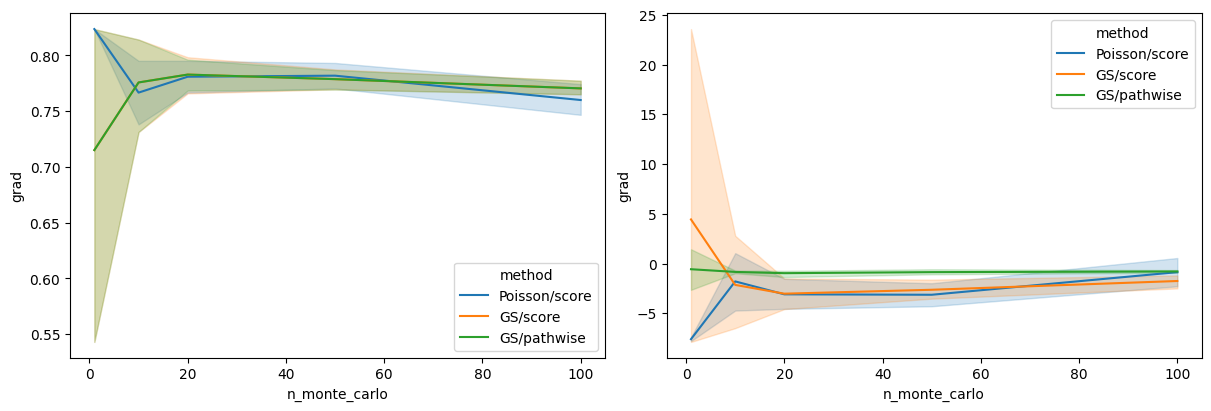

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "generative") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

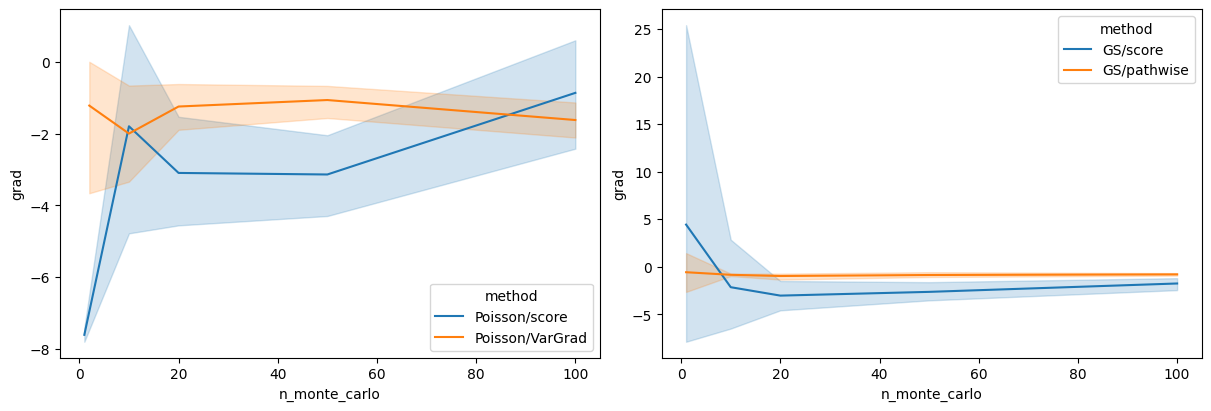

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "Poisson/score") | (df_results["method"]  == "Poisson/VarGrad"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "GS/score") | (df_results["method"]  == "GS/pathwise"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

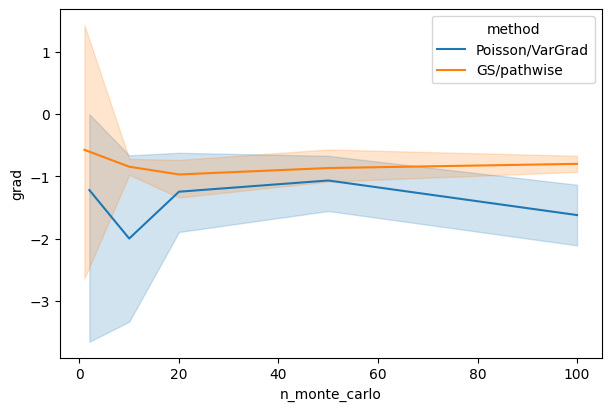

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "GS/pathwise") | (df_results["method"]  == "Poisson/VarGrad"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=ax,
)

In [28]:
df_list = []
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        z_samples = torch.poisson(
            q_rate.unsqueeze(1).expand(
                batch_size, n_monte_carlo, n_time_bins, poglm.n_hid_neurons
            )
        )  # (batch, n_mc, n_time_bins, n_hid_neurons)

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Compute log likelihood
        ln_p = (
            models.poisson_log_prob(
                y_samples,
                p_rate,
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)
        ln_q = (
            models.poisson_log_prob(
                z_samples,
                q_rate.unsqueeze(1).expand(
                    batch_size,
                    n_monte_carlo,
                    n_time_bins,
                    poglm.n_hid_neurons,
                ),
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)

        ln_p_values = ln_p.detach()
        ln_q_values = ln_q.detach()
        elbo_values = ln_p_values - ln_q_values
        elbo = (
            ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        ).mean(
            dim=-1
        )  # (batch,)
        loss = -elbo.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["Poisson/score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

In [29]:
for n_monte_carlo in [2, 10, 20, 50, 100]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        z_samples = torch.poisson(
            q_rate.unsqueeze(1).expand(
                batch_size, n_monte_carlo, n_time_bins, poglm.n_hid_neurons
            )
        ).detach()  # (batch, n_mc, n_time_bins, n_hid_neurons)

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Compute log likelihood
        ln_p = (
            models.poisson_log_prob(
                y_samples,
                p_rate,
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)
        ln_q = (
            models.poisson_log_prob(
                z_samples,
                q_rate.unsqueeze(1).expand(
                    batch_size,
                    n_monte_carlo,
                    n_time_bins,
                    poglm.n_hid_neurons,
                ),
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)

        log_weights = ln_p - ln_q
        logvar_loss = torch.var(-log_weights, correction=1, dim=-1) # (batch,)
        loss = logvar_loss.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["Poisson/VarGrad"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

In [30]:
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_time_bins, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        ).detach()  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(
            z_gs_samples
        )  # (batch, n_mc, n_time_bins, n_hid_neurons

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Compute log likelihood
        ln_p = (
            models.poisson_log_prob(
                y_samples,
                p_rate,
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)
        ln_q = (
            models.poisson_log_prob(
                z_samples,
                q_rate.unsqueeze(1).expand(
                    batch_size,
                    n_monte_carlo,
                    n_time_bins,
                    poglm.n_hid_neurons,
                ),
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)

        ln_p_values = ln_p.detach()
        ln_q_values = ln_q.detach()
        elbo_values = ln_p_values - ln_q_values
        elbo = (
            ln_p - ln_p_values + elbo_values * (ln_q - ln_q_values) + elbo_values
        ).mean(
            dim=-1
        )  # (batch,)
        loss = -elbo.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["GS/score"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

In [31]:
for n_monte_carlo in [1, 10, 20, 50, 100]:
    torch.manual_seed(0)

    poglm = models.POGLM(
        n_vis_neurons=3,
        n_hid_neurons=2,
        kernel_size=3,
    )

    y = y_train[:1, :, :]
    x = y[:, :, :n_vis_neurons]  # (batch, n_time_bins, n_vis_neurons)
    batch_size, n_time_bins, _ = y.shape

    for seed in range(5):
        # Variational rates
        q_rate = poglm.variational(x)  # (batch, n_time_bins, n_hid_neurons)

        # Monte Carlo samples from variational distribution
        q_logit_pi = logit_pi(q_rate)  # (batch, n_time_bins, n_hid_neurons, upperbound)
        z_gs_samples = F.gumbel_softmax(
            q_logit_pi.unsqueeze(1).expand(
                batch_size,
                n_monte_carlo,
                n_time_bins,
                n_hid_neurons,
                8,
            ),
            tau=0.2,
            hard=False,
        )  # (batch, n_mc, n_time_bins, n_hid_neurons, upperbound)
        z_samples = aggregate_samples(
            z_gs_samples
        )  # (batch, n_mc, n_time_bins, n_hid_neurons

        # Combine visible and hidden neurons
        y_samples = torch.cat(
            [
                x.unsqueeze(1).expand(-1, n_monte_carlo, -1, -1),
                z_samples,
            ],
            dim=-1,
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Generative rates
        p_rate = poglm.generative(
            F.pad(
                y_samples.reshape(-1, n_time_bins, poglm.n_neurons),
                (0, 0, poglm.kernel_size, -1),
            )
        ).reshape(
            batch_size, n_monte_carlo, n_time_bins, poglm.n_neurons
        )  # (batch, n_mc, n_time_bins, n_neurons)

        # Compute log likelihood
        ln_p = (
            models.poisson_log_prob(
                y_samples,
                p_rate,
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)
        ln_q = (
            models.poisson_log_prob(
                z_samples,
                q_rate.unsqueeze(1).expand(
                    batch_size,
                    n_monte_carlo,
                    n_time_bins,
                    poglm.n_hid_neurons,
                ),
            )
            .sum(dim=-1)
            .sum(dim=-1)
            # .mean(dim=-1)
        )  # (batch, n_mc)

        elbo = (ln_p - ln_q).mean(dim=-1)  # (batch,)
        loss = -elbo.mean()

        poglm.zero_grad()
        loss.backward()

        df_list.append(
            pd.DataFrame(
                {
                    "n_monte_carlo": [n_monte_carlo] * 2,
                    "seed": [seed] * 2,
                    "method": ["GS/pathwise"] * 2,
                    "part": ["generative", "variational"],
                    "grad": [
                        poglm.conv_generative.weight.grad[0, 0, 0].item(),
                        poglm.conv_variational.weight.grad[0, 0, 0].item(),
                    ],
                },
            )
        )

df_results = pd.concat(df_list, axis=0, ignore_index=True)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

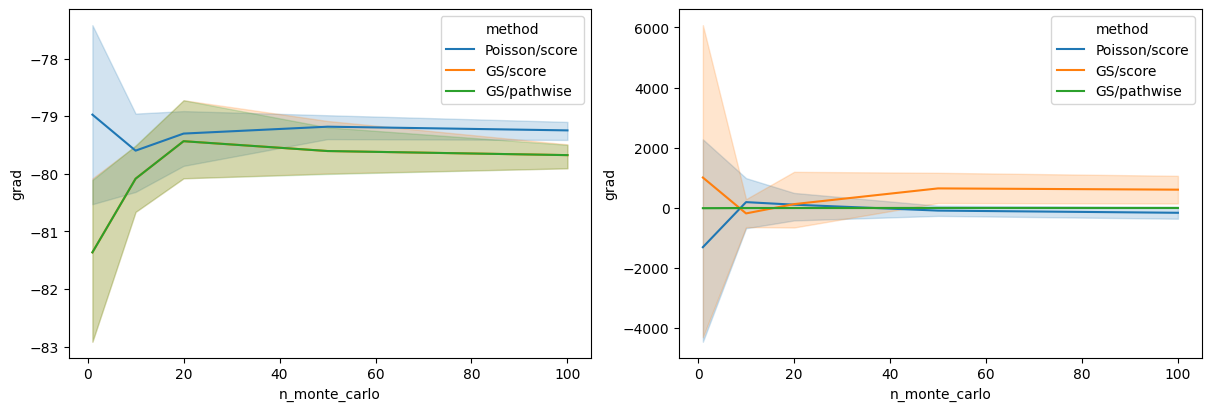

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "generative") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

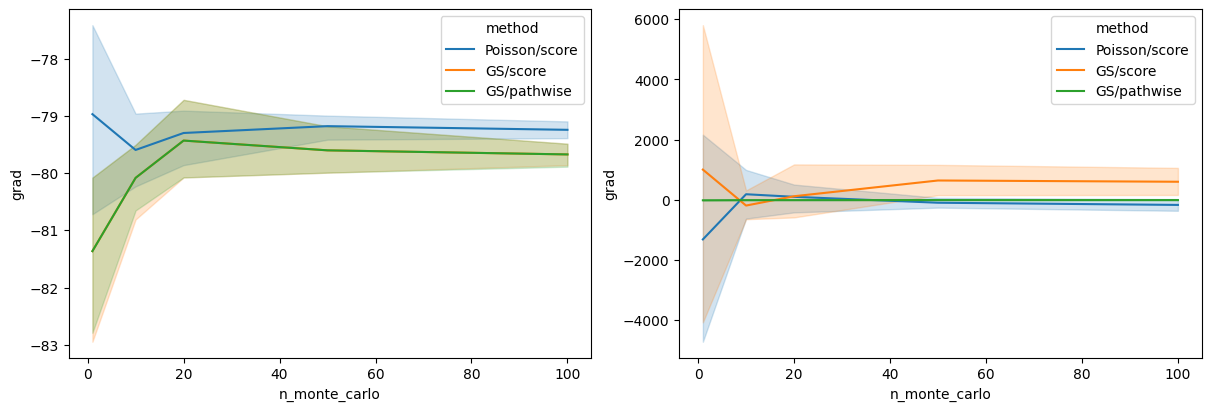

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "generative") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & (df_results["method"] != "Poisson/VarGrad")],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

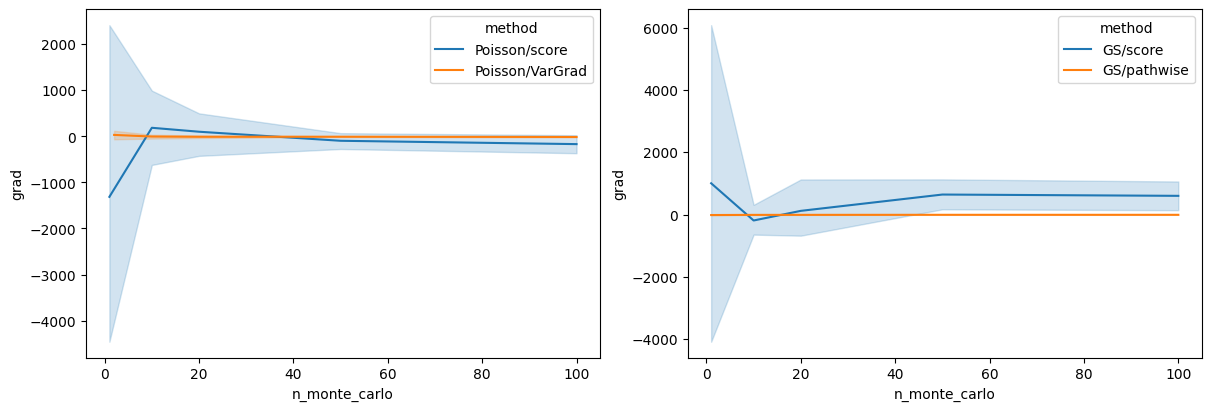

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "Poisson/score") | (df_results["method"]  == "Poisson/VarGrad"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[0],
)
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "GS/score") | (df_results["method"]  == "GS/pathwise"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=axs[1],
)

<Axes: xlabel='n_monte_carlo', ylabel='grad'>

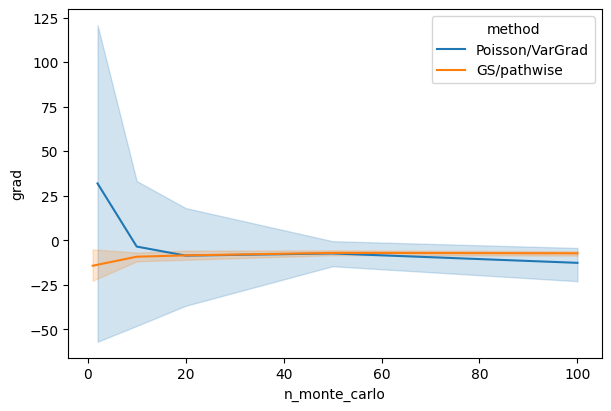

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout="constrained")
sns.lineplot(
    data=df_results[(df_results["part"] == "variational") & ((df_results["method"]  == "GS/pathwise") | (df_results["method"]  == "Poisson/VarGrad"))],
    x="n_monte_carlo",
    y="grad",
    hue="method",
    ax=ax,
)

In [36]:
df_results[df_results["part"] == "variational"]

,n_monte_carlo,seed,method,part,grad
1,1,0,Poisson/score,variational,-5891.115234
3,1,1,Poisson/score,variational,5748.568359
5,1,2,Poisson/score,variational,-537.242981
7,1,3,Poisson/score,variational,-4631.858887
9,1,4,Poisson/score,variational,-1255.122070
...,...,...,...,...,...
191,100,0,GS/pathwise,variational,-8.453070
193,100,1,GS/pathwise,variational,-5.937454
195,100,2,GS/pathwise,variational,-6.297595
197,100,3,GS/pathwise,variational,-6.252333


In [37]:
torch.empty((1000,)).exponential_(3.0).mean().item()

0.3229867219924927

In [38]:
(
    -(
        1
        - torch.rand(
            1000,
        )
    ).log()
    / 3.0
).mean().item()

0.3347017765045166